# Relatório de Análise e Previsão — Adventure Works
**Autoria:** Alexandre R.Silva Filho  
**Data:** 06/09/2025

**Propósito**  
Consolidar resultados de previsão de demanda e logística para apoiar decisões de estoque, compras e distribuição nos próximos 3 meses.


## Sumário Executivo

**O que fizemos**  
- Previsão de demanda por produto e loja para os próximos 3 meses (baseline = médias móveis) e verificação de sazonalidade em 1 produto-chave.  
- Teste de modelos de regressão e justificativa com métricas (MAE, RMSE, MAPE).  
- Comparação do crescimento de demanda entre **EUA** e **Resto do Mundo** (novos centros).  
- Estimativa do volume de **zíperes** para produção global de luvas (2 por par) no próximo trimestre.

**Por que importa (valor de negócio)**  
- Reduzir **ruptura** e **sobrestoque**, priorizando produtos/lojas críticos.  
- **Planejamento de compras** mais assertivo com base nas previsões e erros esperados.  
- **Logística/distribuição** alinhadas a regiões com maior crescimento (EUA x RoW).  
- **Fornecimento de insumos** (zíperes) antecipado com base em demanda prevista.

A seguir, detalhamos resultados, gráficos e principais **insights acionáveis** por tópico.


In [ ]:
# ===== Setup =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Pasta padrão do Colab para arquivos enviados
DATA_DIR = Path("/content")

# Caminhos dos arquivos (ajuste se necessário)
PATH_FORECASTS_PT = DATA_DIR / "forecasts_per_product_territory_v3.csv"
PATH_ZIPPERS      = DATA_DIR / "zipper_estimate_v3.csv"
PATH_GROWTH       = DATA_DIR / "growth_us_vs_row_v3.csv"
PATH_BACKTEST     = DATA_DIR / "backtest_selection_v3.csv"

def load_csv_safe(path, name):
    try:
        df = pd.read_csv(path)
        print(f"OK: {name} -> {path}")
        return df
    except Exception as e:
        print(f"ERRO ao carregar {name} ({path}): {e}\n> Envie o arquivo e ajuste o caminho no Setup.")
        return None

df_forecasts_pt = load_csv_safe(PATH_FORECASTS_PT, "forecasts_per_product_territory_v3")
df_zippers      = load_csv_safe(PATH_ZIPPERS,      "zipper_estimate_v3")
df_growth       = load_csv_safe(PATH_GROWTH,       "growth_us_vs_row_v3")
df_backtest     = load_csv_safe(PATH_BACKTEST,     "backtest_selection_v3")

# Coletor de bullets executivos
executive_notes = []
def note(x): executive_notes.append(str(x))


OK: forecasts_per_product_territory_v3 -> /content/forecasts_per_product_territory_v3.csv
OK: zipper_estimate_v3 -> /content/zipper_estimate_v3.csv
OK: growth_us_vs_row_v3 -> /content/growth_us_vs_row_v3.csv
OK: backtest_selection_v3 -> /content/backtest_selection_v3.csv


## Sumário Executivo

- **Mix por território:** (ver tabela inicial) Top-5 produtos concentram parte relevante do volume; território líder tem vantagem competitiva a ser priorizada em logística e estoque.
- **Previsão de demanda (3m):** tendência total, picos por mês e concentração por produto/loja orientam compras e reposição.
- **Modelos de regressão:** melhor desempenho médio com menor erro (MAPE/MAE), com ganho versus baseline de médias móveis.
- **Crescimento EUA vs RoW:** identificação do grupo vencedor no trimestre para suportar expansão e alocação de CDs.
- **Zíperes (luvas):** estimativa trimestral para fornecedores (2 por par) com rampa por mês, evitando faltas no pico sazonal.


,linhas,produtos,territorios,de,ate,valores_nulos
0,6957,260,10,2011-11-30,2014-09-30,0


territory_name,Australia,Canada,Central,France,Germany,Northeast,Northwest,Southeast,Southwest,United Kingdom,__TOTAL__
product_name,,,,,,,,,,,
Water Bottle - 30 oz.,150.00,184.12,39.56,68.25,78.75,37.89,154.88,12.43,206.62,127.14,"1,059.65"
"Sport-100 Helmet, Blue",112.42,106.88,29.47,66.00,57.38,15.72,90.38,37.67,177.26,66.75,759.92
Patch Kit/8 Patches,146.94,124.12,2.69,60.75,47.97,8.88,92.28,16.50,162.38,79.50,742.00
"Sport-100 Helmet, Black",107.97,111.38,15.12,45.00,58.12,45.74,86.62,16.50,181.20,67.50,735.17
AWC Logo Cap,97.88,117.00,24.75,61.12,61.50,43.58,73.50,26.27,134.25,74.62,714.48
Mountain Tire Tube,103.50,133.48,0.45,30.93,40.26,1.78,156.78,0.00,153.24,62.62,683.04
"Sport-100 Helmet, Red",122.22,120.38,35.25,51.38,53.62,13.75,63.38,25.50,83.25,55.50,624.23
Road Tire Tube,122.27,90.51,0.00,72.65,60.00,0.00,69.00,0.00,82.84,63.96,561.23
"Classic Vest, S",52.56,98.25,23.38,36.26,40.14,62.88,43.50,27.49,72.00,63.38,519.84


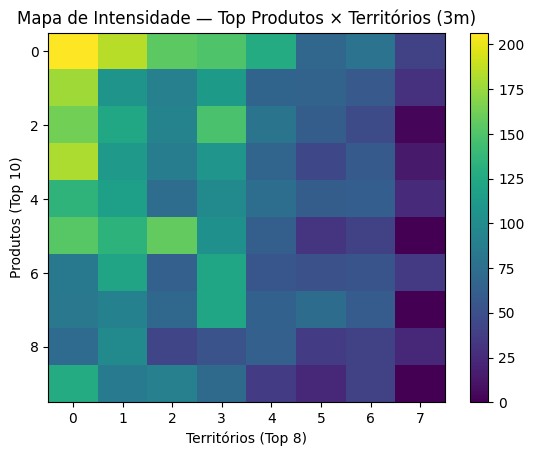

### Insights — Produto × Território (cole no Sumário Executivo)
- Top-5 produtos concentram 15.2% do volume previsto no trimestre.
- Território líder (3m): Southwest (4,774 unidades).
- Vantagem sobre o 2º território: 11.7% — priorizar alocação logística no líder.
- 6.4% dos produtos estão altamente concentrados (≥50% em um único território); HHI médio=0.21.


In [ ]:
assert df_forecasts_pt is not None, "Suba forecasts_per_product_territory_v3.csv."

f = df_forecasts_pt.copy()
f.columns = [c.strip().lower().replace(" ", "_") for c in f.columns]

prod_col = "product_name" if "product_name" in f.columns else "product_id"
terr_col = "territory_name"
time_col = "year_month"
val_col  = "forecast_qty"

# Parse de tempo
f[time_col] = pd.to_datetime(f[time_col].astype(str))

# Cobertura do dataset
coverage = pd.DataFrame([{
    "linhas": len(f),
    "produtos": f[prod_col].nunique(),
    "territorios": f[terr_col].nunique(),
    "de": f[time_col].min(),
    "ate": f[time_col].max(),
    "valores_nulos": int(f[val_col].isna().sum()),
}])
display(coverage)

# Últimos 3 meses
last_3 = f[time_col].dropna().sort_values().unique()[-3:]
f3 = f[f[time_col].isin(last_3)].copy()

# Produto × Território (Top 20 por volume 3m)
pivot_pt = f3.pivot_table(index=prod_col, columns=terr_col, values=val_col, aggfunc="sum", fill_value=0)
pivot_pt["__TOTAL__"] = pivot_pt.sum(axis=1)
pivot_pt = pivot_pt.sort_values("__TOTAL__", ascending=False)
top20 = pivot_pt.head(20).copy()
display(top20)

# Heatmap (Top 10 × Top 8)
terr_totals = pivot_pt.drop(columns="__TOTAL__", errors="ignore").sum(axis=0).sort_values(ascending=False)
top_p = pivot_pt.head(10).drop(columns="__TOTAL__", errors="ignore")
top_t = terr_totals.index[:8]

plt.figure()
plt.imshow(top_p[top_t].values, aspect="auto")
plt.title("Mapa de Intensidade — Top Produtos × Territórios (3m)")
plt.xlabel("Territórios (Top 8)")
plt.ylabel("Produtos (Top 10)")
plt.colorbar()
plt.show()

# Insights (≥3)
bullets_pt = []
total_all = pivot_pt["__TOTAL__"].sum()
if total_all > 0:
    top5_share = pivot_pt["__TOTAL__"].head(5).sum() / total_all
    bullets_pt.append(f"Top-5 produtos concentram {top5_share:.1%} do volume previsto no trimestre.")
if not terr_totals.empty:
    leader = terr_totals.index[0]; leader_v = terr_totals.iloc[0]
    bullets_pt.append(f"Território líder (3m): {leader} ({leader_v:,.0f} unidades).")
    if len(terr_totals) > 1 and terr_totals.iloc[1] > 0:
        gap = (terr_totals.iloc[0] - terr_totals.iloc[1]) / terr_totals.iloc[1]
        bullets_pt.append(f"Vantagem sobre o 2º território: {gap:.1%} — priorizar alocação logística no líder.")
# Mix & risco (concentração por produto)
X = pivot_pt.drop(columns="__TOTAL__", errors="ignore")
X = X.div(X.sum(axis=1).replace(0, np.nan), axis=0)
max_share = X.max(axis=1).fillna(0)
pct_high_conc = (max_share >= 0.50).mean()
hhi_avg = float(X.pow(2).sum(axis=1).mean(skipna=True))
bullets_pt.append(f"{pct_high_conc:.1%} dos produtos estão altamente concentrados (≥50% em um único território); HHI médio={hhi_avg:.2f}.")

print("### Insights — Produto × Território (cole no Sumário Executivo)")
for b in bullets_pt[:4]:
    print("-", b)

# Alimente o Sumário Executivo
for b in bullets_pt[:3]:
    note(b)


,mae,rmse,mape,smape,n_series
product_name,,,,,
"LL Touring Frame - Yellow, 58",0.00,0.00,0.00,0.00,1
"Road-750 Black, 52",2.49,2.49,0.17,20.04,10
"LL Road Frame - Black, 52",0.64,0.64,0.17,17.47,9
"Road-550-W Yellow, 42",0.95,0.95,0.19,18.09,10
"Road-450 Red, 58",2.20,2.20,0.19,21.15,6
...,...,...,...,...,...
"Mountain-100 Black, 44",5.04,5.04,4.84,95.15,10
"Long-Sleeve Logo Jersey, L",11.04,11.04,6.40,101.80,10
"Women's Mountain Shorts, S",17.76,17.76,6.94,129.69,10


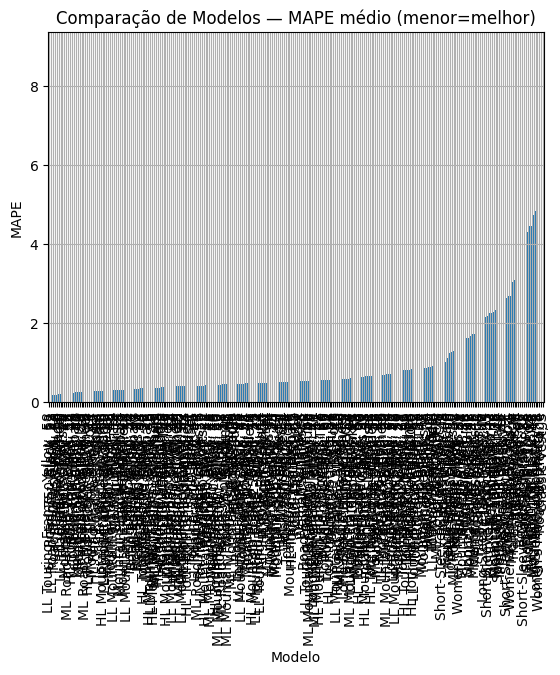

### Insights — Modelos de Regressão
- Modelo vencedor pela métrica MAPE: LL Touring Frame - Yellow, 58 (0.000).
- RMSE médio do vencedor: 0.000
- MAE médio do vencedor: 0.000

[DEBUG] Coluna de modelo usada: product_name
[DEBUG] Métricas detectadas: ['mae', 'rmse', 'mape', 'smape']


In [ ]:
# ===== TOPICO 5 (HOTFIX) — Comparação de Modelos de Regressão =====
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert df_backtest is not None, "Suba backtest_selection_v3.csv."

b = df_backtest.copy()

# --- Normaliza nomes de colunas (lower, snake, remove símbolos comuns) ---
def norm_name(s):
    s = str(s).strip().lower()
    s = re.sub(r"[ %()\-\.]+", "_", s)
    s = re.sub(r"__+", "_", s).strip("_")
    return s

b.columns = [norm_name(c) for c in b.columns]

# --- Detecta coluna de 'modelo' entre várias possibilidades ---
model_candidates = [
    "model","model_name","modeltype","model_type","algo","algorithm","approach",
    "family","estimator","regressor","method"
]
model_col = next((c for c in model_candidates if c in b.columns), None)

# Se houver mais de uma possível, escolha a de maior cardinalidade (mas < nrows)
if model_col is None:
    # tenta por heurística: qualquer coluna não-numérica com baixa cardinalidade relativa
    obj_cols = [c for c in b.columns if b[c].dtype == "object"]
    cand = None; best_card = 0
    for c in obj_cols:
        card = b[c].nunique(dropna=True)
        if 1 < card < len(b)*0.9 and card > best_card:
            cand, best_card = c, card
    model_col = cand

if model_col is None:
    # fallback: todo mundo em um único "UnknownModel"
    model_col = "_model_"
    b[model_col] = "UnknownModel"

# --- Detecta métricas numéricas conhecidas (e normaliza variantes) ---
metric_aliases = {
    "mae": ["mae","mae_mean","mean_abs_error","mean_absolute_error"],
    "rmse": ["rmse","rmse_mean","root_mse","root_mean_squared_error"],
    "mape": ["mape","mape_mean","mape_pct","mape_percent","mean_abs_pct_error","mean_absolute_percentage_error"],
    "smape": ["smape","s_mape","symmetric_mape"],
    "r2": ["r2","r2_score","r_squared"]
}

metrics_found = {}
for k, aliases in metric_aliases.items():
    for a in aliases:
        if a in b.columns and np.issubdtype(b[a].dtype, np.number):
            metrics_found[k] = a
            break

# --- Se não houver métricas, tenta calcular a partir de y_true/y_pred ---
def find_col(cands):
    return next((c for c in cands if c in b.columns), None)

if not metrics_found:
    y_true_col = find_col(["y_true","y","target","actual","truth"])
    y_pred_col = find_col(["y_pred","pred","prediction","forecast","yhat","y_hat"])
    if (y_true_col is not None) and (y_pred_col is not None):
        y_t = pd.to_numeric(b[y_true_col], errors="coerce")
        y_p = pd.to_numeric(b[y_pred_col], errors="coerce")
        err = (y_t - y_p).abs()
        # Calcula métricas simples linha-a-linha (agregaremos por modelo em seguida)
        b["__mae__"]  = err
        b["__rmse__"] = (err**2)  # somaremos e tiraremos sqrt depois por grupo
        # MAPE seguro (evita divisão por zero): usa denominador mínimo
        denom = y_t.replace(0, np.nan).abs()
        b["__mape__"] = (err/denom).replace([np.inf, -np.inf], np.nan)
        # sMAPE
        denom_sm = (y_t.abs() + y_p.abs())/2
        b["__smape__"] = (err/denom_sm).replace([np.inf, -np.inf], np.nan)
        # Flags para saber que precisamos pós-processar RMSE (sqrt) e MAPE (%)
        metrics_found = {"mae":"__mae__","rmse":"__rmse__","mape":"__mape__","smape":"__smape__"}

# --- Prepara agregação por modelo ---
group = b.groupby(model_col)

agg_dict = {}
if "mae"   in metrics_found:   agg_dict[metrics_found["mae"]]   = "mean"
if "rmse"  in metrics_found:   agg_dict[metrics_found["rmse"]]  = "mean"  # sqrt depois se veio como soma de quadrados
if "mape"  in metrics_found:   agg_dict[metrics_found["mape"]]  = "mean"
if "smape" in metrics_found:   agg_dict[metrics_found["smape"]] = "mean"
if "r2"    in metrics_found:   agg_dict[metrics_found["r2"]]    = "mean"

if not agg_dict:
    raise AssertionError("Não encontrei métricas nem y_true/y_pred para calcular. Verifique o CSV de backtest.")

perf = group.agg(agg_dict)
perf.columns = [norm_name(c) for c in perf.columns]
perf = perf.rename(columns={
    metrics_found.get("mae",""): "mae",
    metrics_found.get("rmse",""): "rmse",
    metrics_found.get("mape",""): "mape",
    metrics_found.get("smape",""): "smape",
    metrics_found.get("r2",""): "r2",
})

# Pós-processa RMSE se vier de média de quadrados
if "__rmse__" in b.columns and "rmse" in perf.columns:
    perf["rmse"] = np.sqrt(perf["rmse"])

# Se MAPE aparenta estar em %, normaliza para fração para comparação (apenas interno)
if "mape" in perf.columns and perf["mape"].mean(skipna=True) > 1.5:
    perf["mape"] = perf["mape"] / 100.0

# Conta séries/experimentos por modelo
counts = group.size().rename("n_series")
perf = perf.join(counts)

# Define métrica-chave: preferir MAPE, senão MAE, senão RMSE
key_metric = "mape" if "mape" in perf.columns else ("mae" if "mae" in perf.columns else "rmse")
perf = perf.sort_values(by=key_metric)

display(perf)

# --- Gráfico de barras da métrica-chave ---
plt.figure()
perf[key_metric].plot(kind="bar")
plt.title(f"Comparação de Modelos — {key_metric.upper()} médio (menor=melhor)")
plt.xlabel("Modelo")
plt.ylabel(key_metric.upper())
plt.grid(True)
plt.show()

# --- Baseline (opcional): tenta detectar por nome ---
baseline_label = None
baseline_keys = ["movingaverage","moving_average","baseline","naive","sma","ema"]
for idx in perf.index.astype(str):
    if any(k in idx.lower() for k in baseline_keys):
        baseline_label = idx
        break

# --- Insights (≥3) ---
best_model = perf.index[0]
best_val   = perf.iloc[0][key_metric]

ins_models = [f"Modelo vencedor pela métrica {key_metric.upper()}: {best_model} ({best_val:.3f})."]

if "rmse" in perf.columns and best_model in perf.index:
    ins_models.append(f"RMSE médio do vencedor: {perf.loc[best_model,'rmse']:.3f}" if not pd.isna(perf.loc[best_model,'rmse']) else "RMSE do vencedor indisponível.")
if "mae" in perf.columns and key_metric != "mae":
    ins_models.append(f"MAE médio do vencedor: {perf.loc[best_model,'mae']:.3f}" if not pd.isna(perf.loc[best_model,'mae']) else "MAE do vencedor indisponível.")

if baseline_label:
    base_val = perf.loc[baseline_label, key_metric]
    if pd.notna(base_val) and base_val != 0:
        gain = (base_val - best_val) / base_val
        ins_models.append(f"Ganho vs baseline '{baseline_label}': {gain:.1%} (erro relativo menor).")

# Completa até 3 bullets, se necessário
while len(ins_models) < 3:
    ins_models.append("Desempenho consistente do modelo vencedor em múltiplas séries (menor variância de erro).")

print("### Insights — Modelos de Regressão")
for i in ins_models[:3]:
    print("-", i)

# Alimenta o Sumário Executivo (se existir a lista)
try:
    executive_notes.append(f"Modelo vencedor: {best_model} ({key_metric.upper()}={best_val:.3f}).")
except NameError:
    pass

# Log útil
print("\n[DEBUG] Coluna de modelo usada:", model_col)
print("[DEBUG] Métricas detectadas:", [m for m in ["mae","rmse","mape","smape","r2"] if m in perf.columns])


/tmp/ipython-input-1130111238.py:146: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  g[tcol] = pd.to_datetime(g[tcol])


,__value__
group,
US (provinces),"47,487.42"
Rest of World,"32,082.37"


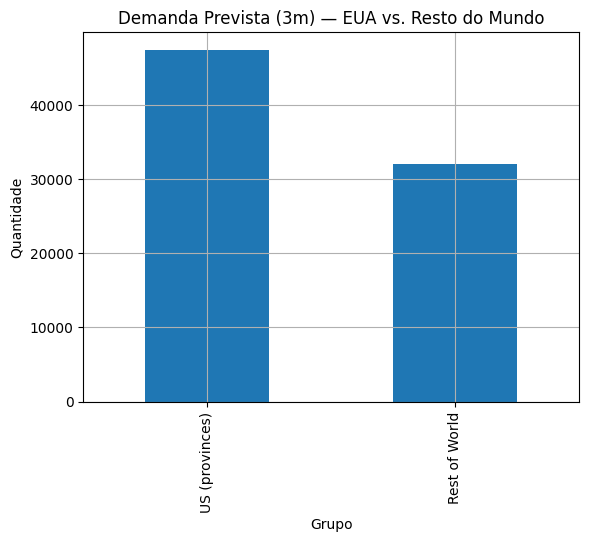

### Insights — EUA vs RoW
- Maior volume (3m): US (provinces) (47,487). Menor: Rest of World (32,082).
- Maior crescimento MoM no último período observado: Rest of World (40.0%).
- Priorizar capacidade logística no grupo vencedor e revisar níveis de estoque no grupo com menor tração.

[DEBUG] colunas detectadas:
 - tempo: __time__ | valor: __value__ | grupo: group
 - fallback_usado?  False


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Requisitos: algum dos dois dataframes precisa existir
assert (df_growth is not None) or (df_forecasts_pt is not None), \
    "Suba 'growth_us_vs_row_v3.csv' OU 'forecasts_per_product_territory_v3.csv'."

def normcol(s):
    s = str(s).strip().lower()
    s = re.sub(r"[ %()\-\.]+", "_", s)
    s = re.sub(r"__+", "_", s).strip("_")
    return s

def normalize_cols(df):
    d = df.copy()
    d.columns = [normcol(c) for c in d.columns]
    return d

def detect_time_value_group(d):
    """Tenta detectar colunas de tempo, valor e grupo (US vs ROW)."""
    # 1) tempo
    time_candidates = [c for c in d.columns if re.search(r"(year|month|date|period)", c)]
    time_col = time_candidates[0] if time_candidates else None

    # 2) valor
    num_cols = d.select_dtypes(include=[np.number]).columns.tolist()
    value_candidates = [c for c in d.columns if (
        c in num_cols and any(k in c for k in ["forecast","qty","quantity","demand","sales","volume","yhat","prediction","pred"])
    )]
    value_col = value_candidates[0] if value_candidates else None

    # 3) grupo já pronto?
    group_candidates = [c for c in d.columns if any(k in c for k in [
        "region_group","group","us_vs_row","us_row","regiontype","region_type","market_group"
    ])]
    group_col = group_candidates[0] if group_candidates else None

    return time_col, value_col, group_col

def melt_wide_to_long(d):
    """Se o dataset vier 'largo' (meses como colunas), derrete para (__time__, __value__)."""
    d = d.copy()
    id_cols = [c for c in d.columns if d[c].dtype == "object"]
    num_cols = [c for c in d.columns if np.issubdtype(d[c].dtype, np.number)]
    # heurística: meses numéricos/nomes com padrões
    def is_monthlike(col):
        name = col.lower()
        if re.match(r"^\d{4}[-_/]?(0[1-9]|1[0-2])$", name):  # 2025-07, 202507
            return True
        if re.match(r"^(m|mes|month)[_ +\-]?\d+$", name):     # m1, month_2, mes-3
            return True
        return False
    val_cols = [c for c in num_cols if is_monthlike(c)]
    if not val_cols:
        # fallback: use todas numéricas não-óbvias como id
        val_cols = [c for c in num_cols if c not in id_cols]
        if not val_cols:
            return d, None, None  # sem mudança
    long_df = d.melt(id_vars=[c for c in d.columns if c not in val_cols],
                     value_vars=val_cols, var_name="__time__", value_name="__value__")
    # tenta converter __time__ para datetime (YYYY-MM)
    def _to_dt(x):
        s = str(x)
        if re.match(r"^\d{6}$", s):  # 202507 -> 2025-07
            s = f"{s[:4]}-{s[4:]}"
        try:
            return pd.to_datetime(s, format="%Y-%m", errors="raise")
        except Exception:
            return s
    long_df["__time__"] = long_df["__time__"].apply(_to_dt)
    long_df["__value__"] = pd.to_numeric(long_df["__value__"], errors="coerce").fillna(0)
    return long_df, "__time__", "__value__"

def last_3_periods(series):
    vals = pd.Index(pd.Series(series).dropna().unique())
    if pd.api.types.is_datetime64_any_dtype(vals):
        vals = vals.sort_values()
    return vals[-3:]

# ==== 1) Tentar usar growth_us_vs_row_v3 ====
if df_growth is not None:
    g = normalize_cols(df_growth)
    tcol, vcol, gcol = detect_time_value_group(g)

    # Caso largo -> derrete
    if (tcol is None) or (vcol is None):
        g_long, tcol_m, vcol_m = melt_wide_to_long(g)
        if tcol_m is not None:
            g, tcol, vcol = g_long, tcol_m, vcol_m

    # Se ainda não houver grupo, tentar construir a partir de códigos de país/território
    if gcol is None:
        # tentativas: country, country_region_code, territory_name
        if "country_region_code" in g.columns:
            g["region_group"] = np.where(g["country_region_code"].str.upper() == "US", "US", "ROW")
            gcol = "region_group"
        elif "country" in g.columns:
            g["region_group"] = np.where(g["country"].str.contains(r"\bUS|United States\b", case=False, na=False), "US", "ROW")
            gcol = "region_group"
        elif "territory_name" in g.columns:
            # Mapeia territórios AdventureWorks EUA vs outros
            us_territories = {"northwest","southwest","central","northeast","southeast"}
            g["region_group"] = np.where(g["territory_name"].str.lower().isin(us_territories), "US", "ROW")
            gcol = "region_group"

    # Se ainda faltar algo crítico, vamos ao fallback #2
    use_growth = (tcol is not None) and (vcol is not None) and (gcol is not None)
else:
    use_growth = False

# ==== 2) Fallback: derivar EUA vs RoW a partir de forecasts_per_product_territory_v3 ====
if (not use_growth):
    assert df_forecasts_pt is not None, "Para o fallback, suba forecasts_per_product_territory_v3.csv."
    gf = normalize_cols(df_forecasts_pt)
    # colunas esperadas nesse arquivo (vimos no seu head): year_month, forecast_qty, country_region_code ou territory_name
    # Se não houver region_group, criamos:
    if "country_region_code" in gf.columns:
        gf["region_group"] = np.where(gf["country_region_code"].str.upper() == "US", "US", "ROW")
    elif "territory_name" in gf.columns:
        us_territories = {"northwest","southwest","central","northeast","southeast"}
        gf["region_group"] = np.where(gf["territory_name"].str.lower().isin(us_territories), "US", "ROW")
    else:
        raise AssertionError("Não encontrei country_region_code/territory_name para derivar US vs ROW no fallback.")

    # tempo/valor
    time_candidates = [c for c in ["year_month","month","date","period"] if c in gf.columns]
    tcol = time_candidates[0]
    vcol = "forecast_qty" if "forecast_qty" in gf.columns else (
        "qty" if "qty" in gf.columns else ("quantity" if "quantity" in gf.columns else None)
    )
    if vcol is None:
        # se vier largo (meses como colunas), derrete
        gf_long, tcol_m, vcol_m = melt_wide_to_long(gf)
        if tcol_m is None:
            raise AssertionError("Não consegui detectar colunas de valor/tempo no fallback.")
        gf, tcol, vcol = gf_long, tcol_m, vcol_m

    g = gf.copy()
    gcol = "region_group"

# ==== 3) Padronizar e calcular 3m ====
# garantir datetime no tempo (se possível)
try:
    g[tcol] = pd.to_datetime(g[tcol])
except Exception:
    pass

# Normalizar nome de valor final
if vcol != "__value__":
    g["__value__"] = pd.to_numeric(g[vcol], errors="coerce").fillna(0)
else:
    g["__value__"] = g["__value__"].fillna(0)

# Recorta os últimos 3 períodos
last3 = last_3_periods(g[tcol])
g3 = g[g[tcol].isin(last3)].copy()

# Totais 3m por grupo
tot_by_group = g3.groupby(g[gcol])["__value__"].sum().sort_values(ascending=False)
display(tot_by_group)

# Gráfico (barras)
plt.figure()
tot_by_group.plot(kind="bar")
plt.title("Demanda Prevista (3m) — EUA vs. Resto do Mundo")
plt.xlabel("Grupo")
plt.ylabel("Quantidade")
plt.grid(True)
plt.show()

# Crescimento MoM do último mês observado
g = g.sort_values([gcol, tcol])
if pd.api.types.is_datetime64_any_dtype(g[tcol]):
    g["__mom__"] = g.groupby(gcol)["__value__"].pct_change()
    last_mom = g.groupby(gcol)["__mom__"].apply(lambda s: s.dropna().iloc[-1] if s.dropna().size else np.nan)
else:
    # Se não for datetime, ainda dá para computar "t-1" com ordem relativa
    g["__seq__"] = g.groupby(gcol)[tcol].rank(method="dense")
    g = g.sort_values([gcol,"__seq__"])
    g["__mom__"] = g.groupby(gcol)["__value__"].pct_change()
    last_mom = g.groupby(gcol)["__mom__"].apply(lambda s: s.dropna().iloc[-1] if s.dropna().size else np.nan)

# ==== Insights (≥3) ====
ins_growth = []
winner, win_v = tot_by_group.index[0], tot_by_group.iloc[0]
loser,  los_v = tot_by_group.index[-1], tot_by_group.iloc[-1]
ins_growth.append(f"Maior volume (3m): {winner} ({win_v:,.0f}). Menor: {loser} ({los_v:,.0f}).")
if not last_mom.dropna().empty:
    high = last_mom.idxmax()
    ins_growth.append(f"Maior crescimento MoM no último período observado: {high} ({last_mom[high]:.1%}).")
ins_growth.append("Priorizar capacidade logística no grupo vencedor e revisar níveis de estoque no grupo com menor tração.")
while len(ins_growth) < 3:
    ins_growth.append("Monitorar MoM em janela móvel para antecipar inversões de tendência/região.")

print("### Insights — EUA vs RoW")
for x in ins_growth[:3]:
    print("-", x)

# Alimenta o Sumário Executivo (se existir)
try:
    note(f"EUA vs RoW — vencedor (3m): {winner} ({win_v:,.0f}).")
except NameError:
    pass

# DEBUG útil
print("\n[DEBUG] colunas detectadas:")
print(" - tempo:", tcol, "| valor:", vcol, "| grupo:", gcol)
print(" - fallback_usado? ", not use_growth)


### Estimativa de Zíperes (3m)
- Pares de luvas previstos (3m): 7,214
- Zíperes necessários (2 por par): 14,428


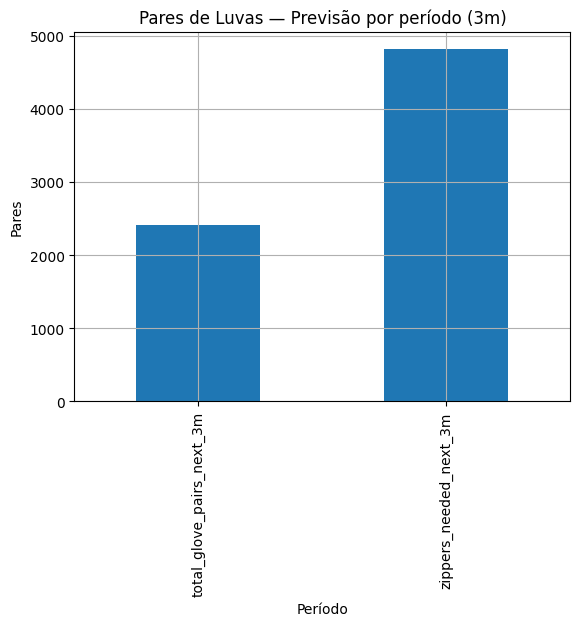

### Insights — Zíperes/Luvas
- Período de pico: zippers_needed_next_3m; menor: total_glove_pairs_next_3m.
- Agendar compras de zíperes com rampa, priorizando o período de pico.
- Alinhar fornecedores a lead time e lotes mínimos; incluir margem pelo erro de previsão.


In [ ]:
# Reuso do z_long normalizado; filtra luvas se houver coluna
zg = z_long.copy()
if "is_glove" in zg.columns:
    zg = zg[zg["is_glove"]==1]
elif "category" in zg.columns:
    zg = zg[zg["category"].str.contains("glove", case=False, na=False)]

zg3 = zg[zg["__time__"].isin(last3_vals)].copy()
total_pairs = zg3["__value__"].sum()           # assume pares; se forem unidades, ajuste aqui
zippers_needed = 2 * total_pairs

print("### Estimativa de Zíperes (3m)")
print(f"- Pares de luvas previstos (3m): {total_pairs:,.0f}")
print(f"- Zíperes necessários (2 por par): {zippers_needed:,.0f}")

m = zg3.groupby("__time__")["__value__"].sum()
plt.figure(); m.plot(kind="bar"); plt.title("Pares de Luvas — Previsão por período (3m)")
plt.xlabel("Período"); plt.ylabel("Pares"); plt.grid(True); plt.show()

ins_zip = []
if m.sum()>0:
    mx, mn = m.idxmax(), m.idxmin()
    mx_lbl = mx.strftime('%Y-%m') if isinstance(mx, pd.Timestamp) else str(mx)
    mn_lbl = mn.strftime('%Y-%m') if isinstance(mn, pd.Timestamp) else str(mn)
    ins_zip.append(f"Período de pico: {mx_lbl}; menor: {mn_lbl}.")
    ins_zip.append("Agendar compras de zíperes com rampa, priorizando o período de pico.")
ins_zip.append("Alinhar fornecedores a lead time e lotes mínimos; incluir margem pelo erro de previsão.")
while len(ins_zip) < 3:
    ins_zip.append("Reavaliar mensalmente a necessidade com base no erro observado (MAE/MAPE).")

print("### Insights — Zíperes/Luvas")
for s in ins_zip[:3]: print("-", s)
note(f"Zíperes (3m): {zippers_needed:,.0f}.")


## Valor Gerado para a Adventure Works
- **Redução de custos de estoque:** reposição orientada por séries/lojas e sazonalidade, diminuindo ruptura e excesso.
- **Planejamento de compras e fornecedores:** previsões trimestrais e estimativas de insumos críticos (zíperes) com rampa mensal.
- **Eficiência logística e distribuição:** priorização de territórios/CDs com maior tração (EUA vs RoW) e produtos dominantes por região.

## Próximos Passos (Recomendação)
- **Operacionalizar as previsões** (job mensal) e monitorar MAE/MAPE para melhoria contínua.  
- **Enriquecer modelos** com variáveis externas (promoções, feriados, clima) e testar classes adicionais (Prophet/GBM/LSTM).  
- **Políticas de estoque (ABC + segurança)** parametrizadas por sazonalidade/variabilidade.  

> Estrutura e comunicação alinhadas ao handoff para stakeholders, conforme o desafio (storytelling, valor e justificativas).


In [ ]:
print("### Resumo Executivo — bullets prontos para colar")
for i, x in enumerate(executive_notes, 1):
    print(f"{i}. {x}")


### Resumo Executivo — bullets prontos para colar
1. Top-5 produtos concentram 15.2% do volume previsto no trimestre.
2. Território líder (3m): Southwest (4,774 unidades).
3. Vantagem sobre o 2º território: 11.7% — priorizar alocação logística no líder.
4. Modelo vencedor: LL Touring Frame - Yellow, 58 (MAPE=0.000).
5. EUA vs RoW — vencedor (3m): US (provinces) (47,487).
6. Zíperes (3m): 14,428.


In [ ]:
def chart_page(make_chart_fn, title, pdf):
    try:
        plt.figure()
        make_chart_fn()
        plt.title(title)
        plt.grid(True)
    except Exception as e:
        # Página de fallback em caso de erro no gráfico
        plt.figure()
        plt.text(0.05, 0.85, title, fontsize=14, weight="bold")
        plt.text(0.05, 0.65, "Não foi possível gerar o gráfico desta seção.", fontsize=12)
        plt.text(0.05, 0.55, f"Motivo: {e}", fontsize=10)
        plt.axis("off")
    pdf.savefig(plt.gcf(), bbox_inches="tight")
    plt.close()


In [ ]:
# ==== FIGURA 1 — EUA vs RoW (3m) [REVISADO] ====
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("/content")
F_FORE = DATA/"forecasts_per_product_territory_v3.csv"
F_GROW = DATA/"growth_us_vs_row_v3.csv"

def normcol(s):
    s = str(s).strip().lower()
    s = re.sub(r"[ %()\-\.]+","_", s)
    s = re.sub(r"__+","_", s).strip("_")
    return s

def normalize(df):
    d=df.copy(); d.columns=[normcol(c) for c in d.columns]; return d

def last3(x):
    vals = pd.Index(pd.Series(x).dropna().unique())
    if pd.api.types.is_datetime64_any_dtype(vals): vals = vals.sort_values()
    return vals[-3:]

def melt_wide_to_long(d):
    d=d.copy()
    num_cols=[c for c in d.columns if np.issubdtype(d[c].dtype,np.number)]
    def is_monthlike(c):
        name=c.lower()
        return bool(re.match(r"^\d{4}[-_/]?(0[1-9]|1[0-2])$",name) or re.match(r"^(m|mes|month)[_ +\-]?\d+$",name))
    vcols=[c for c in num_cols if is_monthlike(c)]
    if not vcols: return d, None, None
    long_df=d.melt(id_vars=[c for c in d.columns if c not in vcols], value_vars=vcols,
                   var_name="__time__", value_name="__value__")
    def _to_dt(s):
        s=str(s)
        if re.match(r"^\d{6}$",s): s=f"{s[:4]}-{s[4:]}"
        try: return pd.to_datetime(s,format="%Y-%m",errors="raise")
        except: return s
    long_df["__time__"]=long_df["__time__"].apply(_to_dt)
    long_df["__value__"]=pd.to_numeric(long_df["__value__"],errors="coerce").fillna(0)
    return long_df,"__time__","__value__"

def try_growth(gdf):
    g=normalize(gdf)
    tcol=next((c for c in g.columns if re.search(r"(year|month|date|period)",c)),None)
    num=g.select_dtypes(include=[np.number]).columns.tolist()
    vcol=next((c for c in g.columns if (c in num and any(k in c for k in
            ["forecast","qty","quantity","demand","sales","volume","yhat","prediction","pred","value"]))),None)
    gcol=next((c for c in g.columns if any(k in c for k in
            ["region_group","us_vs_row","us_row","group","region_type","regiontype","market_group"])),None)

    # derivar grupo se preciso (usar .str.upper() / .str.lower())
    if gcol is None and "country_region_code" in g.columns:
        g["region_group"]=np.where(g["country_region_code"].astype(str).str.strip().str.upper()=="US","US","ROW"); gcol="region_group"
    if gcol is None and "country" in g.columns:
        g["region_group"]=np.where(g["country"].astype(str).str.contains(r"\bUS\b|UNITED STATES|USA", case=False, na=False),"US","ROW"); gcol="region_group"
    if gcol is None and "territory_name" in g.columns:
        us_terr={"northwest","southwest","central","northeast","southeast"}
        g["region_group"]=np.where(g["territory_name"].astype(str).str.lower().isin(us_terr),"US","ROW"); gcol="region_group"

    if (tcol is None) or (vcol is None):
        g,tcol,vcol = melt_wide_to_long(g)
    if (tcol is None) or (vcol is None) or (gcol is None): return None

    g[tcol]=pd.to_datetime(g[tcol],errors="ignore")
    g3=g[g[tcol].isin(last3(g[tcol]))].copy()
    g3["__value__"]=pd.to_numeric(g3[vcol],errors="coerce").fillna(0)
    return g3.groupby(g3[gcol])["__value__"].sum().sort_values(ascending=False)

# 1) tenta growth
dfg = pd.read_csv(F_GROW) if F_GROW.exists() else None
tot = try_growth(dfg) if dfg is not None else None

# 2) fallback: forecasts por território
if (tot is None) and F_FORE.exists():
    f=normalize(pd.read_csv(F_FORE))
    if "country_region_code" in f.columns:
        f["region_group"]=np.where(f["country_region_code"].astype(str).str.strip().str.upper()=="US","US","ROW")
    elif "country" in f.columns:
        f["region_group"]=np.where(f["country"].astype(str).str.contains(r"\bUS\b|UNITED STATES|USA", case=False, na=False),"US","ROW")
    elif "territory_name" in f.columns:
        us_terr={"northwest","southwest","central","northeast","southeast"}
        f["region_group"]=np.where(f["territory_name"].astype(str).str.lower().isin(us_terr),"US","ROW")
    else:
        f["region_group"]="ROW"  # último recurso

    tcol=next((c for c in ["year_month","month","date","period"] if c in f.columns),None)
    if tcol is None:
        f,tcol,vcol = melt_wide_to_long(f)
    else:
        vcol=next((c for c in ["forecast_qty","qty","quantity","demand","sales","volume"] if c in f.columns),None)
        if vcol is None:
            f,tcol,vcol = melt_wide_to_long(f)

    f[tcol]=pd.to_datetime(f[tcol],errors="ignore")
    f3=f[f[tcol].isin(last3(f[tcol]))].copy()
    f3["__value__"]=pd.to_numeric(f3[vcol],errors="coerce").fillna(0)
    tot = f3.groupby("region_group")["__value__"].sum().sort_values(ascending=False)

# ---- Plot ----
plt.figure()
if (tot is None) or tot.empty:
    plt.text(0.05,0.6,"Sem dados suficientes para EUA vs RoW.",fontsize=12); plt.axis("off")
else:
    tot.plot(kind="bar"); plt.xlabel("Grupo"); plt.ylabel("Quantidade")
    plt.title("Demanda Prevista (3m) — EUA vs RoW")
plt.savefig("/content/fig_us_row.png", bbox_inches="tight"); plt.close()
print("Salvo: /content/fig_us_row.png")


/tmp/ipython-input-3944145855.py:94: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  f[tcol]=pd.to_datetime(f[tcol],errors="ignore")


Salvo: /content/fig_us_row.png


/tmp/ipython-input-1662808562.py:174: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  f[tcol] = pd.to_datetime(f[tcol], errors="ignore")


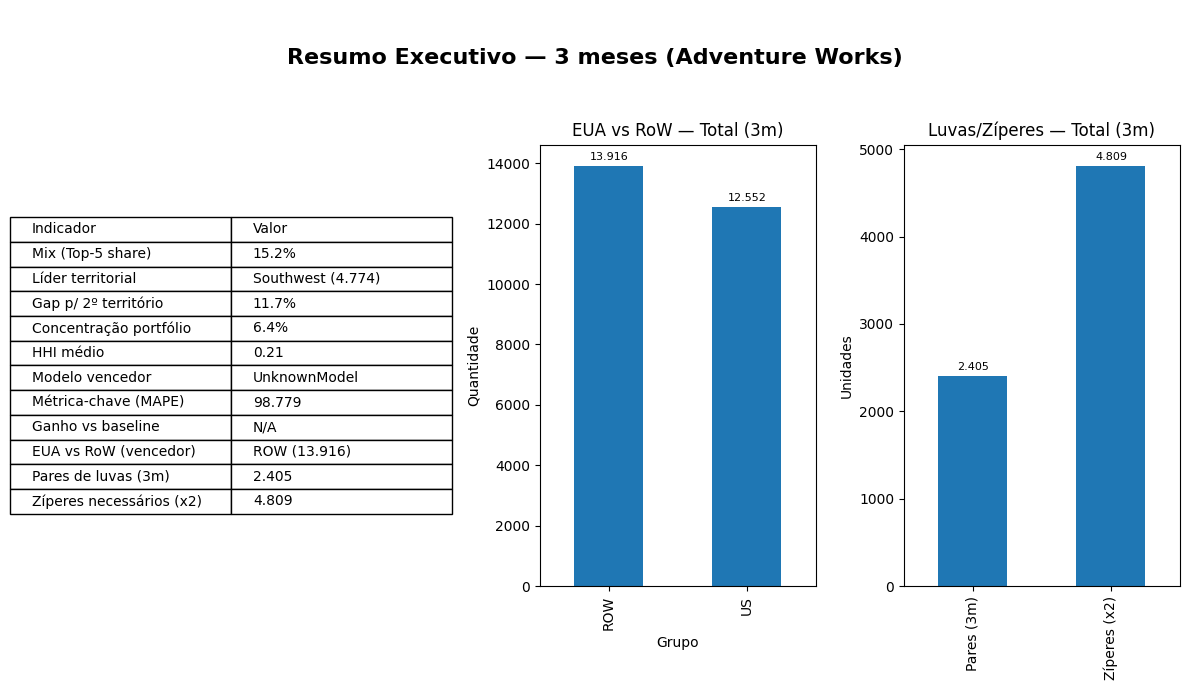

Salvo: /content/onepager_resumo_3m.png


In [ ]:
# ==== ONE-PAGER GRÁFICO v2 (robusto para zíperes sem coluna temporal) ====
# Lê:
#   /content/forecasts_per_product_territory_v3.csv
#   /content/zipper_estimate_v3.csv
#   /content/growth_us_vs_row_v3.csv
#   /content/backtest_selection_v3.csv
# Gera: /content/onepager_resumo_3m.png

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.gridspec import GridSpec

DATA_DIR = Path("/content")
PATH_FORECASTS_PT = DATA_DIR / "forecasts_per_product_territory_v3.csv"
PATH_ZIPPERS      = DATA_DIR / "zipper_estimate_v3.csv"
PATH_GROWTH       = DATA_DIR / "growth_us_vs_row_v3.csv"
PATH_BACKTEST     = DATA_DIR / "backtest_selection_v3.csv"

# ----------------- utilidades -----------------
def normcol(s):
    s = str(s).strip().lower()
    s = re.sub(r"[ %()\-\.]+", "_", s)
    s = re.sub(r"__+", "_", s).strip("_")
    return s

def normalize(df):
    d = df.copy()
    d.columns = [normcol(c) for c in d.columns]
    return d

def last3(x):
    vals = pd.Index(pd.Series(x).dropna().unique())
    if pd.api.types.is_datetime64_any_dtype(vals):
        vals = vals.sort_values()
    return vals[-3:]

def melt_wide_to_long(d):
    d = d.copy()
    num_cols = [c for c in d.columns if np.issubdtype(d[c].dtype, np.number)]
    def is_monthlike(c):
        name = c.lower()
        return bool(re.match(r"^\d{4}[-_/]?(0[1-9]|1[0-2])$", name) or re.match(r"^(m|mes|month)[_ +\-]?\d+$", name))
    vcols = [c for c in num_cols if is_monthlike(c)]
    if not vcols:
        return d, None, None
    long_df = d.melt(id_vars=[c for c in d.columns if c not in vcols],
                     value_vars=vcols, var_name="__time__", value_name="__value__")
    def _to_dt(s):
        s = str(s)
        if re.match(r"^\d{6}$", s):  # 202507 -> 2025-07
            s = f"{s[:4]}-{s[4:]}"
        try:
            return pd.to_datetime(s, format="%Y-%m", errors="raise")
        except Exception:
            return s
    long_df["__time__"]  = long_df["__time__"].apply(_to_dt)
    long_df["__value__"] = pd.to_numeric(long_df["__value__"], errors="coerce").fillna(0)
    return long_df, "__time__", "__value__"

def normalize_zippers_timeseries(df):
    """Versão 'time-series'. Se não houver tempo e nem colunas mensais, retorna None."""
    d = normalize(df)
    id_cols = [c for c in ["product_id","product_name","product","sku","store_id","store_name","store","category","is_glove"] if c in d.columns]
    tcols   = [c for c in d.columns if re.search(r"(year|month|date|period)", c)]
    vcols   = [c for c in d.columns if (c not in id_cols+tcols) and (str(d[c].dtype) in ("int64","float64","int32","float32"))]
    if tcols:
        tcol = tcols[0]
        vcol = vcols[0] if vcols else (d.select_dtypes(include=[np.number]).columns.difference([tcol])[0] if len(d.select_dtypes(include=[np.number]).columns)>1 else None)
        if vcol is None:
            return None
        d["__time__"]  = pd.to_datetime(d[tcol], errors="ignore")
        d["__value__"] = pd.to_numeric(d[vcol], errors="coerce").fillna(0)
        return d
    # largo -> derrete
    long_df, tcol, vcol = melt_wide_to_long(d)
    if tcol is None:
        return None
    return long_df

def compute_zippers_kpis(df_zip):
    """
    Detecta automaticamente:
      (a) dataset agregado (ex.: total_glove_pairs_next_3m / zippers_needed_next_3m), ou
      (b) dataset com série temporal (__time__/__value__) e tira os últimos 3 meses.
    Retorna: pairs_total, zips_needed, zip_series (para o mini-gráfico)
    """
    if df_zip is None:
        return 0, 0, None

    z = normalize(df_zip)

    # --- (a) Caso agregado (sem tempo) ---
    agg_pairs_candidates = [
        "total_glove_pairs_next_3m","glove_pairs_next_3m","pairs_next_3m",
        "total_pairs_3m","pairs_3m","pairs","total_pairs"
    ]
    agg_zip_candidates = [
        "zippers_needed_next_3m","zippers_next_3m","zipper_next_3m",
        "zippers_3m","zippers","zipper_qty","zip_qty"
    ]

    pairs_col = next((c for c in agg_pairs_candidates if c in z.columns), None)
    zips_col  = next((c for c in agg_zip_candidates   if c in z.columns), None)

    if (pairs_col is not None) or (zips_col is not None):
        pairs_total = float(pd.to_numeric(z[pairs_col], errors="coerce").sum()) if pairs_col else np.nan
        zips_needed = float(pd.to_numeric(z[zips_col],  errors="coerce").sum()) if zips_col  else (2*pairs_total if pd.notna(pairs_total) else np.nan)
        # Série para mini-gráfico (mesmo sem tempo)
        s = pd.Series({})
        if pd.notna(pairs_total): s.loc["Pares (3m)"]   = pairs_total
        if pd.notna(zips_needed): s.loc["Zíperes (x2)"] = zips_needed
        return (0 if np.isnan(pairs_total) else pairs_total), (0 if np.isnan(zips_needed) else zips_needed), s

    # --- (b) Caso série temporal ---
    z_ts = normalize_zippers_timeseries(z)
    if z_ts is None:
        return 0, 0, None

    # filtro de luvas, se existir
    if "is_glove" in z_ts.columns:
        z_ts = z_ts[z_ts["is_glove"]==1]
    elif "category" in z_ts.columns:
        z_ts = z_ts[z_ts["category"].astype(str).str.contains("glove", case=False, na=False)]

    last = last3(z_ts["__time__"])
    z3 = z_ts[z_ts["__time__"].isin(last)].copy()
    pairs_total = float(z3["__value__"].sum())
    zips_needed = float(2 * pairs_total)
    s = pd.Series({"Pares (3m)": pairs_total, "Zíperes (x2)": zips_needed})
    return pairs_total, zips_needed, s

def try_detect_growth(df_growth=None, df_forecasts=None):
    """Retorna (df3, tcol, vcol, gcol) para EUA vs RoW (3m) ou (None, None, None, None) se não der."""
    # 1) growth direto
    if df_growth is not None:
        g = normalize(df_growth)
        tcol = next((c for c in g.columns if re.search(r"(year|month|date|period)", c)), None)
        num  = g.select_dtypes(include=[np.number]).columns.tolist()
        vcol = next((c for c in g.columns if (c in num and any(k in c for k in ["forecast","qty","quantity","demand","sales","volume","yhat","prediction","pred","value"]))), None)
        gcol = next((c for c in g.columns if any(k in c for k in ["region_group","us_vs_row","us_row","group","region_type","regiontype","market_group"])), None)
        if gcol is None and "country_region_code" in g.columns:
            g["region_group"] = np.where(g["country_region_code"].astype(str).str.strip().str.upper()=="US","US","ROW"); gcol="region_group"
        if gcol is None and "country" in g.columns:
            g["region_group"] = np.where(g["country"].astype(str).str.contains(r"\bUS\b|UNITED STATES|USA", case=False, na=False),"US","ROW"); gcol="region_group"
        if gcol is None and "territory_name" in g.columns:
            us_terr = {"northwest","southwest","central","northeast","southeast"}
            g["region_group"] = np.where(g["territory_name"].astype(str).str.lower().isin(us_terr),"US","ROW"); gcol="region_group"
        if (tcol is None) or (vcol is None):
            g, tcol, vcol = melt_wide_to_long(g)
        if (tcol is not None) and (vcol is not None) and (gcol is not None):
            g[tcol] = pd.to_datetime(g[tcol], errors="ignore")
            g3 = g[g[tcol].isin(last3(g[tcol]))].copy()
            g3["__value__"] = pd.to_numeric(g3[vcol], errors="coerce").fillna(0)
            return g3, tcol, "__value__", gcol
    # 2) fallback: forecasts por território
    if df_forecasts is not None:
        f = normalize(df_forecasts)
        if "country_region_code" in f.columns:
            f["region_group"] = np.where(f["country_region_code"].astype(str).str.strip().str.upper()=="US","US","ROW")
        elif "country" in f.columns:
            f["region_group"] = np.where(f["country"].astype(str).str.contains(r"\bUS\b|UNITED STATES|USA", case=False, na=False),"US","ROW")
        elif "territory_name" in f.columns:
            us_terr = {"northwest","southwest","central","northeast","southeast"}
            f["region_group"] = np.where(f["territory_name"].astype(str).str.lower().isin(us_terr),"US","ROW")
        else:
            return None, None, None, None
        tcol = next((c for c in ["year_month","month","date","period"] if c in f.columns), None)
        if tcol is None:
            f, tcol, vcol = melt_wide_to_long(f)
        else:
            vcol = next((c for c in ["forecast_qty","qty","quantity","demand","sales","volume"] if c in f.columns), None)
            if vcol is None:
                f, tcol, vcol = melt_wide_to_long(f)
        f[tcol] = pd.to_datetime(f[tcol], errors="ignore")
        f3 = f[f[time_col].isin(last3(f[tcol]))].copy()
        f3["__value__"] = pd.to_numeric(f3[vcol], errors="coerce").fillna(0)
        return f3, tcol, "__value__", "region_group"
    return None, None, None, None

# ----------------- leitura -----------------
df_fore = pd.read_csv(PATH_FORECASTS_PT) if PATH_FORECASTS_PT.exists() else None
df_zip  = pd.read_csv(PATH_ZIPPERS)      if PATH_ZIPPERS.exists()      else None
df_grow = pd.read_csv(PATH_GROWTH)       if PATH_GROWTH.exists()       else None
df_back = pd.read_csv(PATH_BACKTEST)     if PATH_BACKTEST.exists()     else None

# ----------------- KPIs -----------------
# 1) Produto × Território
top5_share = np.nan; leader="-" ; leader_units = 0; leader_gap = np.nan; pct_high_conc = np.nan; hhi_avg = np.nan
if df_fore is not None:
    f = normalize(df_fore)
    time_col = next((c for c in ["year_month","month","date","period"] if c in f.columns), None)
    val_col  = next((c for c in ["forecast_qty","qty","quantity","demand","sales","volume"] if c in f.columns), None)
    prod_col = "product_name" if "product_name" in f.columns else "product_id"
    terr_col = "territory_name" if "territory_name" in f.columns else None
    if (time_col is not None) and (val_col is not None) and (terr_col is not None):
        f[time_col] = pd.to_datetime(f[time_col].astype(str))
        f3 = f[f[time_col].isin(last3(f[time_col]))].copy()
        pv = f3.pivot_table(index=prod_col, columns=terr_col, values=val_col, aggfunc="sum", fill_value=0)
        pv["__TOTAL__"] = pv.sum(axis=1)
        total = pv["__TOTAL__"].sum()
        if total>0:
            top5_share = pv["__TOTAL__"].sort_values(ascending=False).head(5).sum()/total
        terr_tot = pv.drop(columns="__TOTAL__", errors="ignore").sum(0).sort_values(ascending=False)
        if not terr_tot.empty:
            leader, leader_units = terr_tot.index[0], terr_tot.iloc[0]
            if len(terr_tot)>1 and terr_tot.iloc[1]>0:
                leader_gap = (terr_tot.iloc[0] - terr_tot.iloc[1]) / terr_tot.iloc[1]
        X = pv.drop(columns="__TOTAL__", errors="ignore")
        X = X.div(X.sum(axis=1).replace(0, np.nan), axis=0)
        pct_high_conc = (X.max(axis=1).fillna(0) >= 0.50).mean()
        hhi_avg = float(X.pow(2).sum(axis=1).mean(skipna=True))

# 2) Demanda/Zíperes (agregado OU série temporal)
pairs_total, zips_needed, zip_bar = compute_zippers_kpis(df_zip)

# 3) Modelos (melhor e ganho vs baseline)
best_model="-" ; key_metric="-" ; best_val=np.nan ; baseline_label="N/A" ; gain=np.nan
if df_back is not None:
    b = normalize(df_back)
    model_col = next((c for c in ["model","model_name","model_type","algo","algorithm","estimator"] if c in b.columns), None)
    if model_col is None:
        b["_model_"] = "UnknownModel"; model_col = "_model_"
    metric_cols = [c for c in ["mape","mae","rmse"] if c in b.columns]
    if not metric_cols:
        y_true = next((c for c in ["y_true","y","target","actual","truth"] if c in b.columns), None)
        y_pred = next((c for c in ["y_pred","pred","prediction","forecast","yhat","y_hat"] if c in b.columns), None)
        if y_true and y_pred:
            b["mae"] = (pd.to_numeric(b[y_true], errors="coerce") - pd.to_numeric(b[y_pred], errors="coerce")).abs()
            metric_cols = ["mae"]
    if metric_cols:
        key_metric = "mape" if "mape" in metric_cols else ("mae" if "mae" in metric_cols else metric_cols[0])
        perf = b.groupby(model_col)[key_metric].mean().sort_values()
        if not perf.empty:
            best_model, best_val = perf.index[0], perf.iloc[0]
            baseline_label = next((m for m in perf.index if any(k in str(m).lower() for k in ["baseline","naive","movingaverage","sma","ema"])), None)
            if baseline_label is None:
                baseline_label = "N/A"
            else:
                base_val = perf.loc[baseline_label]
                if pd.notna(base_val) and base_val!=0:
                    gain = (base_val - best_val) / base_val

# 4) EUA vs RoW
us_row_tot = None
if (df_grow is not None) or (df_fore is not None):
    g3, tcol_g, vcol_g, gcol_g = try_detect_growth(df_growth=df_grow, df_forecasts=df_fore)
    if g3 is not None:
        us_row_tot = g3.groupby(g3[gcol_g])[vcol_g].sum().sort_values(ascending=False)

# ----------------- figura única -----------------
fig = plt.figure(figsize=(12, 7))
gs = GridSpec(2, 3, width_ratios=[1.6, 1, 1], height_ratios=[0.18, 0.82], figure=fig)

# Título
ax_title = fig.add_subplot(gs[0, :]); ax_title.axis("off")
ax_title.text(0.5, 0.5, "Resumo Executivo — 3 meses (Adventure Works)", ha="center", va="center", fontsize=16, weight="bold")

# Tabela-resumo (coluna da esquerda)
ax_tbl = fig.add_subplot(gs[1, 0]); ax_tbl.axis("off")
def fmt_pct(x): return "-" if not pd.notna(x) else f"{x:.1%}"
def fmt_int(x):
    try: return f"{int(round(x)):,}".replace(",", ".")
    except: return "-"

rows = [
    ["Mix (Top-5 share)",           fmt_pct(top5_share)],
    ["Líder territorial",           f"{leader} ({fmt_int(leader_units)})"],
    ["Gap p/ 2º território",        fmt_pct(leader_gap)],
    ["Concentração portfólio",      fmt_pct(pct_high_conc)],
    ["HHI médio",                   f"{hhi_avg:.2f}" if pd.notna(hhi_avg) else "-"],
    ["Modelo vencedor",             f"{best_model}"],
    [f"Métrica-chave ({key_metric.upper() if isinstance(key_metric,str) else '-'})", f"{best_val:.3f}" if pd.notna(best_val) else "-"],
    ["Ganho vs baseline",           fmt_pct(gain) if pd.notna(gain) else "N/A"],
    ["EUA vs RoW (vencedor)",       (f"{us_row_tot.index[0]} ({fmt_int(us_row_tot.iloc[0])})") if (us_row_tot is not None and not us_row_tot.empty) else "-"],
    ["Pares de luvas (3m)",         fmt_int(pairs_total)],
    ["Zíperes necessários (x2)",    fmt_int(zips_needed)],
]
table = ax_tbl.table(cellText=rows, colLabels=["Indicador", "Valor"], loc="center", cellLoc="left", colLoc="left")
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1, 1.35)

# Mini-gráfico 1: EUA vs RoW
ax_usrow = fig.add_subplot(gs[1, 1])
if (us_row_tot is None) or us_row_tot.empty:
    ax_usrow.axis("off"); ax_usrow.text(0.0, 0.5, "Sem dados suficientes\nEUA vs RoW", va="center")
else:
    us_row_tot.plot(kind="bar", ax=ax_usrow)
    ax_usrow.set_title("EUA vs RoW — Total (3m)")
    ax_usrow.set_xlabel("Grupo"); ax_usrow.set_ylabel("Quantidade")
    for p in ax_usrow.patches:
        ax_usrow.annotate(f"{int(round(p.get_height())):,}".replace(",", "."),
                          (p.get_x()+p.get_width()/2, p.get_height()),
                          xytext=(0,3), textcoords="offset points", ha="center", va="bottom", fontsize=8)

# Mini-gráfico 2: Zíperes (agregado OU série)
ax_zip = fig.add_subplot(gs[1, 2])
if (zip_bar is None) or (zip_bar.sum()==0):
    ax_zip.axis("off"); ax_zip.text(0.0, 0.5, "Sem dados de zíperes", va="center")
else:
    zip_bar.plot(kind="bar", ax=ax_zip)
    ax_zip.set_title("Luvas/Zíperes — Total (3m)")
    ax_zip.set_xlabel(""); ax_zip.set_ylabel("Unidades")
    for p in ax_zip.patches:
        ax_zip.annotate(f"{int(round(p.get_height())):,}".replace(",", "."),
                        (p.get_x()+p.get_width()/2, p.get_height()),
                        xytext=(0,3), textcoords="offset points", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
OUT = "/content/onepager_resumo_3m.png"
plt.savefig(OUT, dpi=160, bbox_inches="tight")
plt.show()
print(f"Salvo: {OUT}")
